# Tile Price Prediction — Exploratory Data Analysis

This notebook processes the raw JSON lines data, extracts flat features from nested structures, engineers new features, and conducts an exploratory data analysis to identify key drivers of tile pricing.

## 1. Load Raw Data

In [74]:
import pandas as pd
import numpy as np
import json, re
import matplotlib.pyplot as plt
import seaborn as sns
import os

os.makedirs('../outputs', exist_ok=True)

train_rows = []
with open('../data/train.jsonl') as f:
    for line in f:
        train_rows.append(json.loads(line))
train_df = pd.DataFrame(train_rows)

test_rows = []
with open('../data/test.jsonl') as f:
    for line in f:
        test_rows.append(json.loads(line))
test_df = pd.DataFrame(test_rows)

print(f'Train: {train_df.shape}, Test: {test_df.shape}')

Train: (2272, 60), Test: (568, 59)


## 2. Parse Nested Fields

In [75]:
def get_val(f):
    if isinstance(f, dict): return f.get('value', None)
    return None

def get_is_exact(f):
    if isinstance(f, dict):
        comp = f.get('comparator', None)
        if comp == '=':         return 1
        elif comp in ['<','>']: return 0
    return None

def get_pei(f):
    if isinstance(f, dict):
        raw = f.get('value', None)
        m = re.search(r'(\d+)', str(raw)) if raw else None
        return float(m.group(1)) if m else None
    return None

def get_r_rating(f):
    if isinstance(f, dict):
        raw = f.get('value', None)
        m = re.search(r'(\d+)', str(raw)) if raw else None
        return int(m.group(1)) if m else None
    return None

def get_pendulum_class(f):
    if isinstance(f, dict):
        raw = f.get('value', None)
        m = re.search(r'(\d+)', str(raw)) if raw else None
        return int(m.group(1)) if m else None
    return None

def get_barefoot(f):
    if isinstance(f, dict):
        raw = f.get('value', None)
        if raw:
            m = re.search(r'Class ([A-C])', str(raw))
            if m: return ord(m.group(1)) - ord('A')
    return None

numeric_nested = [
    'product_width','product_length','product_thickness',
    'water_absorption_rate','breaking_strength','modulus_of_rupture',
    'mohs_surface_hardness','area_per_box','box_weight',
    'area_per_pallet','loaded_pallet_weight'
]

for df in [train_df, test_df]:
    for col in numeric_nested:
        if col in df.columns:
            df[col+'_val'] = pd.to_numeric(df[col].apply(get_val), errors='coerce')
            df[col+'_is_exact'] = df[col].apply(get_is_exact)

    df['pei_value']    = df['pei_wear_rating'].apply(get_pei)
    df['dcof_value']   = pd.to_numeric(df['dcof_rating'].apply(get_val), errors='coerce')
    df['r_rating_val'] = df['r_rating'].apply(get_r_rating)
    df['pendulum_val'] = df['pendulum_slip_class'].apply(get_pendulum_class)
    df['barefoot_val'] = df['barefoot_wet_slip_rating'].apply(get_barefoot)

    df['pieces_per_box_num']  = pd.to_numeric(df['pieces_per_box'],  errors='coerce')
    df['boxes_per_pallet_num']= pd.to_numeric(df['boxes_per_pallet'], errors='coerce')

print('Parsing done.')

Parsing done.


## 3. Feature Engineering

In [76]:
for df in [train_df, test_df]:
    df['tile_area_mm2']   = df['product_width_val'] * df['product_length_val']
    df['tile_volume_mm3'] = df['tile_area_mm2'] * df['product_thickness_val']
    df['aspect_ratio']    = df['product_length_val'] / (df['product_width_val'] + 1e-6)

    def extract_finish(name):
        if not isinstance(name, str): return 'Other'
        n = name.upper()
        if 'PULIDO'   in n: return 'Pulido'
        if 'BRILLO'   in n: return 'Brillo'
        if 'ANTISLIP' in n: return 'Antislip'
        if 'SATINADO' in n: return 'Satinado'
        if 'LAPPATO'  in n: return 'Lappato'
        if 'MATE'     in n: return 'Mate'
        return 'Other'
    df['finish_keyword'] = df['product_name'].apply(extract_finish)

    def app_combo(locs):
        if not isinstance(locs, list): return 'Unknown'
        s = set(locs)
        if 'Wall' in s and 'Floor' in s: return 'Wall+Floor'
        if 'Wall' in s:  return 'Wall only'
        if 'Floor' in s: return 'Floor only'
        return 'Other'
    df['app_combo'] = df['application_location'].apply(app_combo)

    if 'is_glazed' in df.columns:
        df['is_glazed_int'] = df['is_glazed'].apply(
            lambda x: 1 if x is True else (0 if x is False else -1)
        )

    flag_cols = [
        'pei_value','dcof_value','mohs_surface_hardness_val',
        'water_absorption_rate_val','breaking_strength_val',
        'modulus_of_rupture_val','r_rating_val','barefoot_val','pendulum_val'
    ]
    for col in flag_cols:
        if col in df.columns:
            df[col + '_is_missing'] = df[col].isnull().astype(int)

train_df['log_price'] = np.log(train_df['price_usd_per_sqm'])

print('Feature engineering done.')

Feature engineering done.


In [77]:
col_stats = train_df.groupby('collection_name')['price_usd_per_sqm'].agg(
    collection_mean_price='mean',
    collection_median_price='median',
    collection_std_price='std',
    collection_min_price='min',
    collection_max_price='max',
    collection_count='count'
).reset_index()
col_log = train_df.groupby('collection_name')['log_price'].agg(
    collection_mean_log_price='mean',
    collection_std_log_price='std'
).reset_index()
col_stats = col_stats.merge(col_log, on='collection_name')

train_df = train_df.merge(col_stats, on='collection_name', how='left')
test_df  = test_df.merge(col_stats,  on='collection_name', how='left')

## Chart 1 — Price Distribution

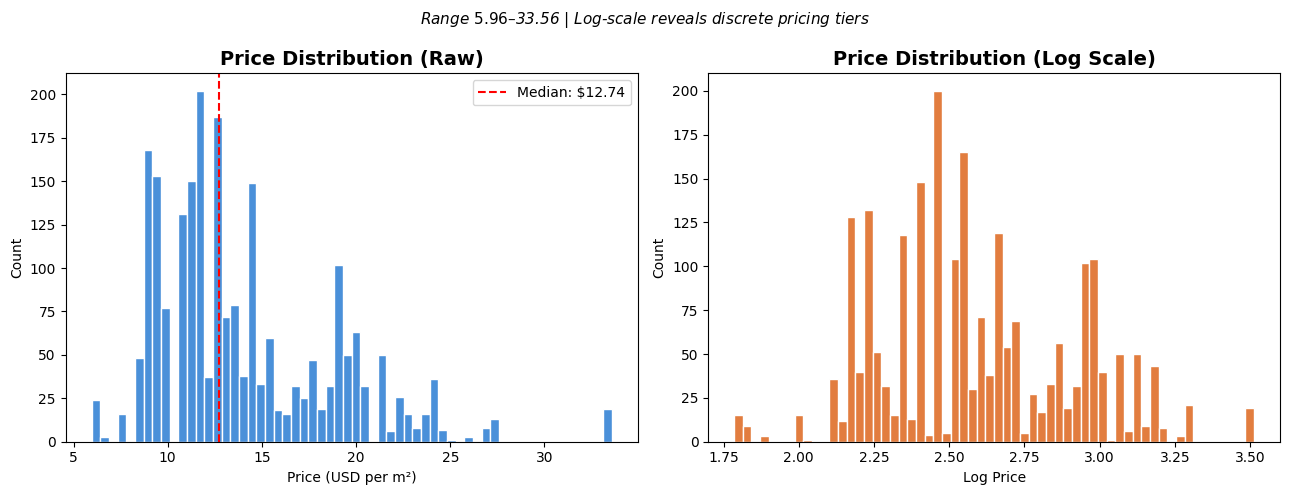

In [78]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(train_df['price_usd_per_sqm'], bins=60, color='#4A90D9', edgecolor='white')
axes[0].set_title('Price Distribution (Raw)', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Price (USD per m²)')
axes[0].set_ylabel('Count')
med = train_df['price_usd_per_sqm'].median()
axes[0].axvline(med, color='red', linestyle='--', label=f'Median: ${med:.2f}')
axes[0].legend()

axes[1].hist(train_df['log_price'], bins=60, color='#E27D3F', edgecolor='white')
axes[1].set_title('Price Distribution (Log Scale)', fontsize=14, fontweight='bold')
axes[1].set_xlabel('Log Price')
axes[1].set_ylabel('Count')

plt.suptitle('Range $5.96–$33.56 | Log-scale reveals discrete pricing tiers', fontsize=11, style='italic')
plt.tight_layout()
plt.savefig('../outputs/chart1_price_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** The log-scale plot reveals discrete pricing brackets (tall spikes at fixed log-price intervals), suggesting structured manufacturer pricing tiers rather than a continuous distribution. We use log(price) as our target for modelling.

## Chart 2 — Tile Volume vs Price

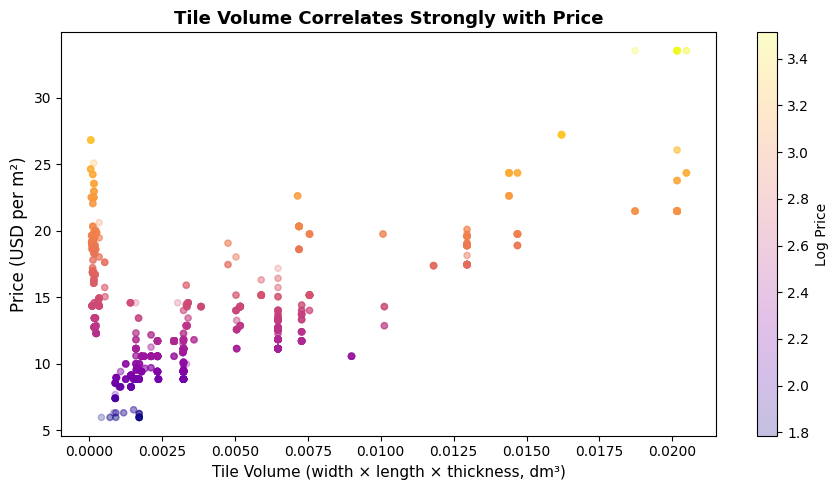

In [79]:
plot_df = train_df.dropna(subset=['tile_volume_mm3', 'price_usd_per_sqm'])

plt.figure(figsize=(9, 5))
sc = plt.scatter(
    plot_df['tile_volume_mm3'] / 1e9, 
    plot_df['price_usd_per_sqm'],
    alpha=0.25, c=plot_df['log_price'], cmap='plasma', s=20
)
plt.colorbar(sc, label='Log Price')
plt.xlabel('Tile Volume (width × length × thickness, dm³)', fontsize=11)
plt.ylabel('Price (USD per m²)', fontsize=12)
plt.title('Tile Volume Correlates Strongly with Price', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart2_volume_vs_price.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Tile volume (width × length × thickness) has a strong positive correlation with price. Larger, thicker tiles cost more to manufacture and transport. The vertical spread at the same volume indicates that other features (like collection or finish) also heavily influence price.

## Chart 3 — Finish Type vs Price

/tmp/ipykernel_20456/1378795841.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


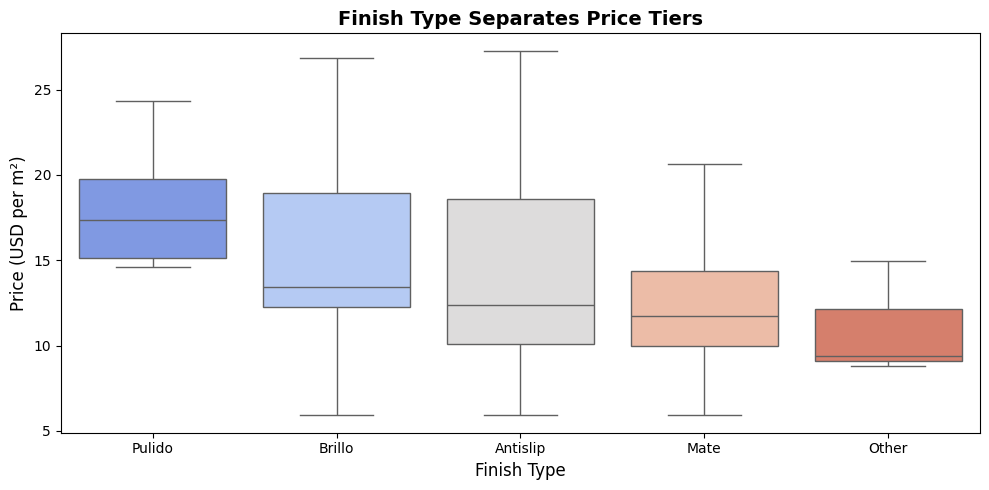

In [80]:
finish_order = (
    train_df.groupby('finish_keyword')['price_usd_per_sqm']
    .median().sort_values(ascending=False).index
)
plt.figure(figsize=(10, 5))
sns.boxplot(
    data=train_df, x='finish_keyword', y='price_usd_per_sqm',
    order=finish_order, palette='coolwarm', showfliers=False
)
plt.xlabel('Finish Type', fontsize=12)
plt.ylabel('Price (USD per m²)', fontsize=12)
plt.title('Finish Type Separates Price Tiers', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart3_price_by_finish.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Finish type extracted from the product name is highly discriminative. Polished (Pulido) tiles command a significant premium over matte (Mate) tiles.

## Chart 4 — Numeric Feature Correlations

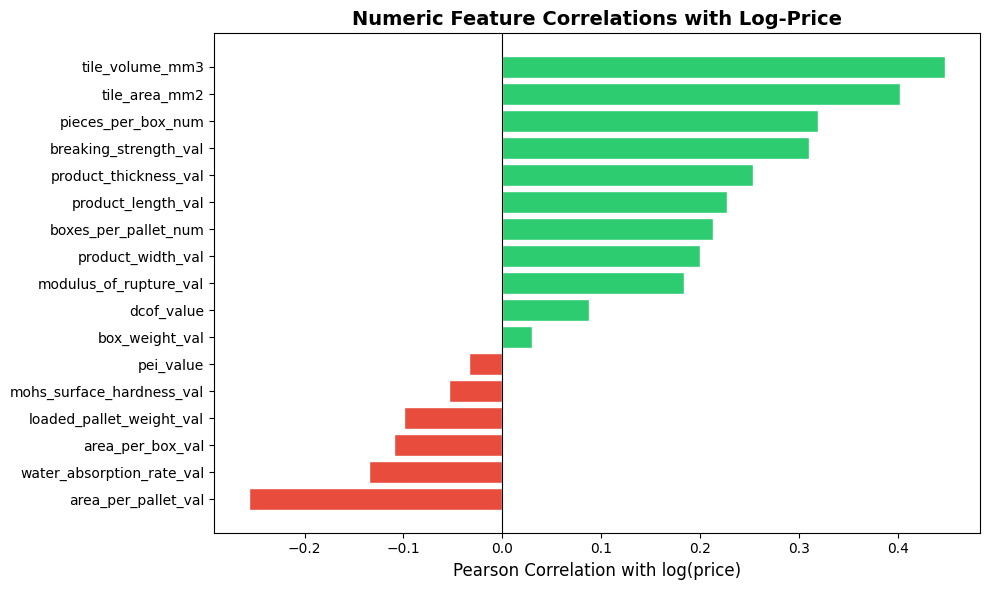

In [81]:
num_cols = [
    'tile_volume_mm3','tile_area_mm2','pieces_per_box_num','breaking_strength_val',
    'product_thickness_val','product_length_val','boxes_per_pallet_num','product_width_val',
    'modulus_of_rupture_val','dcof_value','box_weight_val','pei_value',
    'mohs_surface_hardness_val','loaded_pallet_weight_val','area_per_box_val',
    'water_absorption_rate_val','area_per_pallet_val','log_price'
]
avail = [c for c in num_cols if c in train_df.columns]
num_df = train_df[avail].apply(pd.to_numeric, errors='coerce')
corr = num_df.corr()['log_price'].drop('log_price').sort_values()

colors = ['#E74C3C' if v < 0 else '#2ECC71' for v in corr.values]
plt.figure(figsize=(10, 6))
plt.barh(corr.index, corr.values, color=colors, edgecolor='white')
plt.axvline(0, color='black', linewidth=0.8)
plt.xlabel('Pearson Correlation with log(price)', fontsize=12)
plt.title('Numeric Feature Correlations with Log-Price', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('../outputs/chart4_correlations.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Tile volume is the strongest positive numeric predictor, followed by area and dimensions. Technical ratings like breaking strength also demonstrate a moderate positive correlation.

## Chart 5 — Body Type vs Price

/tmp/ipykernel_20456/751022090.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=train_df, x='body_type', y='price_usd_per_sqm', order=bt_order, palette='Set2', showfliers=False)


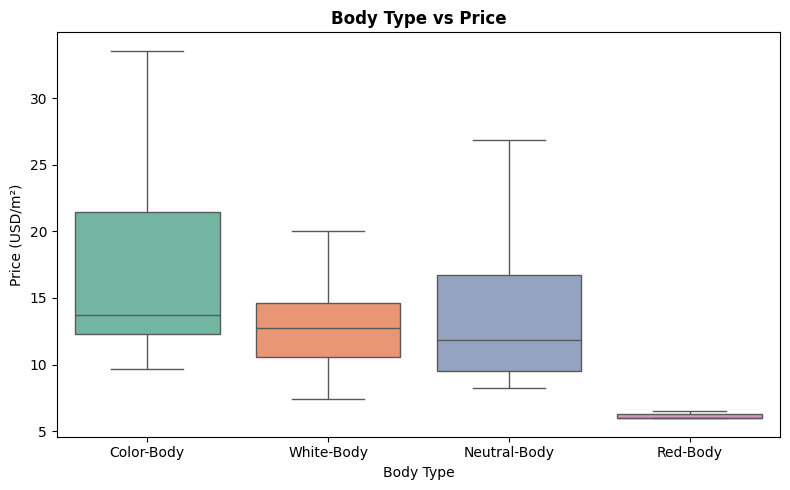

In [82]:
plt.figure(figsize=(8, 5))
bt_order = train_df.groupby('body_type')['price_usd_per_sqm'].median().sort_values(ascending=False).index
sns.boxplot(data=train_df, x='body_type', y='price_usd_per_sqm', order=bt_order, palette='Set2', showfliers=False)
plt.title('Body Type vs Price', fontweight='bold')
plt.xlabel('Body Type')
plt.ylabel('Price (USD/m²)')
plt.tight_layout()
plt.savefig('../outputs/chart5_body_type.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Color-Body tiles are generally priced higher than Red-Body tiles, reflecting differences in material composition and manufacturing costs.

## Chart 6 — Shade Variation vs Price

/tmp/ipykernel_20456/1992871248.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=sv_df, x='shade_variation_rating', y='price_usd_per_sqm', order=sv_order, palette='Set1', showfliers=False)


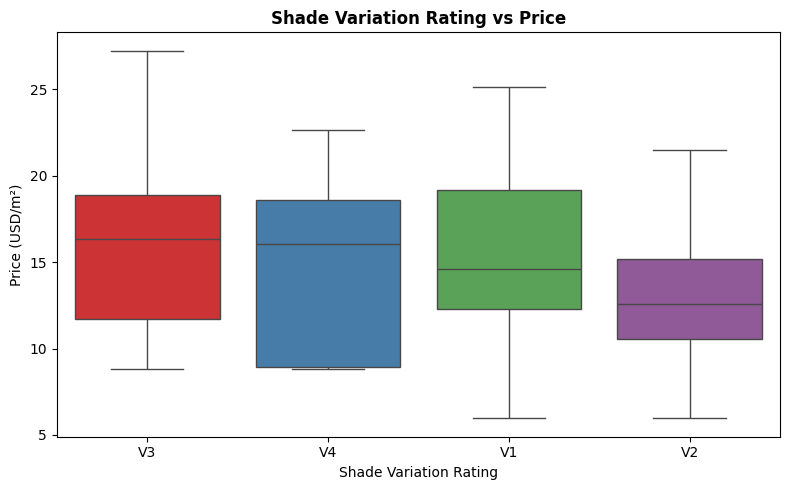

In [83]:
plt.figure(figsize=(8, 5))
sv_order = train_df.groupby('shade_variation_rating')['price_usd_per_sqm'].median().sort_values(ascending=False).index
sv_df = train_df.dropna(subset=['shade_variation_rating'])
sns.boxplot(data=sv_df, x='shade_variation_rating', y='price_usd_per_sqm', order=sv_order, palette='Set1', showfliers=False)
plt.title('Shade Variation Rating vs Price', fontweight='bold')
plt.xlabel('Shade Variation Rating')
plt.ylabel('Price (USD/m²)')
plt.tight_layout()
plt.savefig('../outputs/chart6_shade_variation.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Tiles with higher shade variation (V3/V4) are systematically more expensive than lower variation tiles (V1/V2), likely due to the complexity of printing highly variable patterns.

## Chart 7 — Edge Type vs Price

/tmp/ipykernel_20456/48763067.py:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=et_df, x='edge_type', y='price_usd_per_sqm', order=et_order, palette='Set3', showfliers=False)


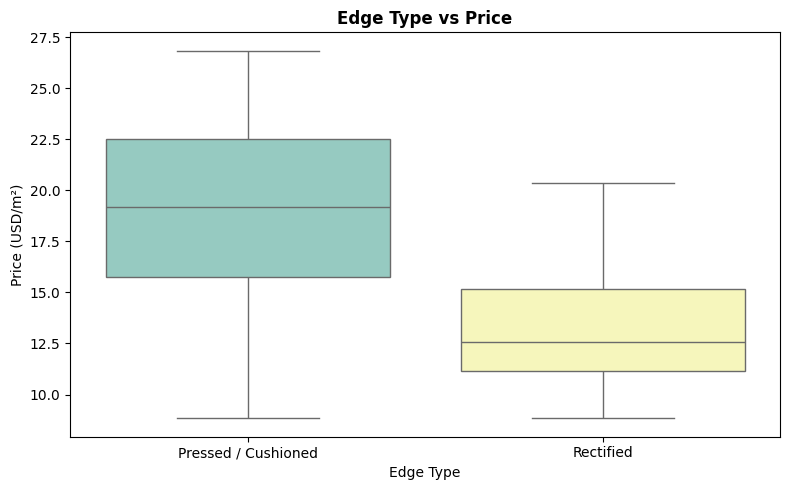

In [84]:
plt.figure(figsize=(8, 5))
et_df = train_df.dropna(subset=['edge_type'])
et_order = et_df.groupby('edge_type')['price_usd_per_sqm'].median().sort_values(ascending=False).index
sns.boxplot(data=et_df, x='edge_type', y='price_usd_per_sqm', order=et_order, palette='Set3', showfliers=False)
plt.title('Edge Type vs Price', fontweight='bold')
plt.xlabel('Edge Type')
plt.ylabel('Price (USD/m²)')
plt.tight_layout()
plt.savefig('../outputs/chart7_edge_type.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Pressed/Cushioned edge tiles command a premium over Rectified edge tiles in this dataset.

## Chart 8 — Barefoot Slip Rating vs Price

/tmp/ipykernel_20456/1718604834.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=bf_df, x='barefoot_label', y='price_usd_per_sqm', order=['Class A','Class B','Class C'], palette='rocket', showfliers=False)


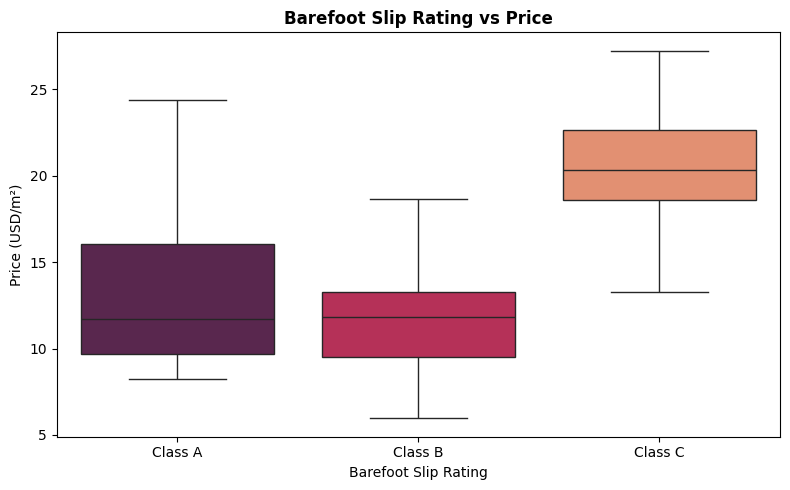

In [85]:
plt.figure(figsize=(8, 5))
bf_df = train_df.dropna(subset=['barefoot_val']).copy()
bf_map = {0:'Class A', 1:'Class B', 2:'Class C'}
bf_df['barefoot_label'] = bf_df['barefoot_val'].map(bf_map)
sns.boxplot(data=bf_df, x='barefoot_label', y='price_usd_per_sqm', order=['Class A','Class B','Class C'], palette='rocket', showfliers=False)
plt.title('Barefoot Slip Rating vs Price', fontweight='bold')
plt.xlabel('Barefoot Slip Rating')
plt.ylabel('Price (USD/m²)')
plt.tight_layout()
plt.savefig('../outputs/chart8_barefoot.png', dpi=150, bbox_inches='tight')
plt.show()

**Observation:** Higher slip resistance ratings (Class C) correlate with higher prices, indicating that specialized high-grip tiles are priced at a premium.

## Save Processed Data

In [86]:
train_df.to_pickle('../outputs/train_processed.pkl')
test_df.to_pickle('../outputs/test_processed.pkl')
print(f'Saved. Train: {train_df.shape}, Test: {test_df.shape}')

Saved. Train: (2272, 113), Test: (568, 111)
